In [1]:
import pandas as pd
import numpy as np

print("environment OK")

environment OK


In [2]:
import os
os.getcwd()
os.chdir('/Users/jeffreybloodworth/Desktop/git-repos/scRNAseq-ExplainableML')

In [3]:
import pandas as pd

meta = pd.read_csv(
    "data/raw/GSE227690_BM_metadata.tsv.gz",
    sep="\t"
)

print(meta.shape)
meta.head()

(20411, 15)


,cell,orig.ident,orig.ident2,nCount_RNA,nFeature_RNA,replicate,tech,UMAP_1,UMAP_2,S.Score,G2M.Score,Phase,CellType,bm_involvement,is_malignant
0,CACTTCGTCATTCATC-BM1.1,BM,BM1,47165,5893,BM1.1,TenX,-7.786632,7.734703,0.513253,0.352306,S,EarlyEry,HD,Other
1,AGTCATGTCGAAGCAG-BM1.1,BM,BM1,45886,5285,BM1.1,TenX,-4.643771,7.509163,-0.087773,0.338163,G2M,EarlyEry,HD,Other
2,CACGAATTCAAGAATG-BM1.1,BM,BM1,39179,5775,BM1.1,TenX,-4.943479,8.777322,0.491249,0.088568,S,EarlyEry,HD,Other
3,CAGCAATCACCTGCGA-BM1.1,BM,BM1,40266,5480,BM1.1,TenX,-5.577019,7.700279,0.149069,0.320633,G2M,EarlyEry,HD,Other
4,GACAGCCAGCTGGAGT-BM1.1,BM,BM1,38745,6029,BM1.1,TenX,-6.510436,8.313575,0.586671,0.169929,S,EarlyEry,HD,Other


In [4]:
print(meta.shape)


(20411, 15)


In [5]:
meta.columns.tolist()

['cell',
 'orig.ident',
 'orig.ident2',
 'nCount_RNA',
 'nFeature_RNA',
 'replicate',
 'tech',
 'UMAP_1',
 'UMAP_2',
 'S.Score',
 'G2M.Score',
 'Phase',
 'CellType',
 'bm_involvement',
 'is_malignant']

In [6]:
meta["CellType"].value_counts()

CellType
Mono              2555
LateEry           1931
CD4Naive          1832
EarlyEry          1796
B                 1508
CD4Memory         1389
NK                1371
CD8TermExh        1190
ProMono           1186
HSPC               910
CD8Memory          801
CD8Naive           779
NKT                626
cDC                619
ProB               534
GMP                278
GammaDeltaLike     261
Plasma             228
ncMono             220
pDC                203
PreB               194
Name: count, dtype: int64

In [7]:
meta["is_malignant"].value_counts()

is_malignant
Other      20208
Healthy      203
Name: count, dtype: int64

In [8]:
meta["bm_involvement"].value_counts()

bm_involvement
HD    20411
Name: count, dtype: int64

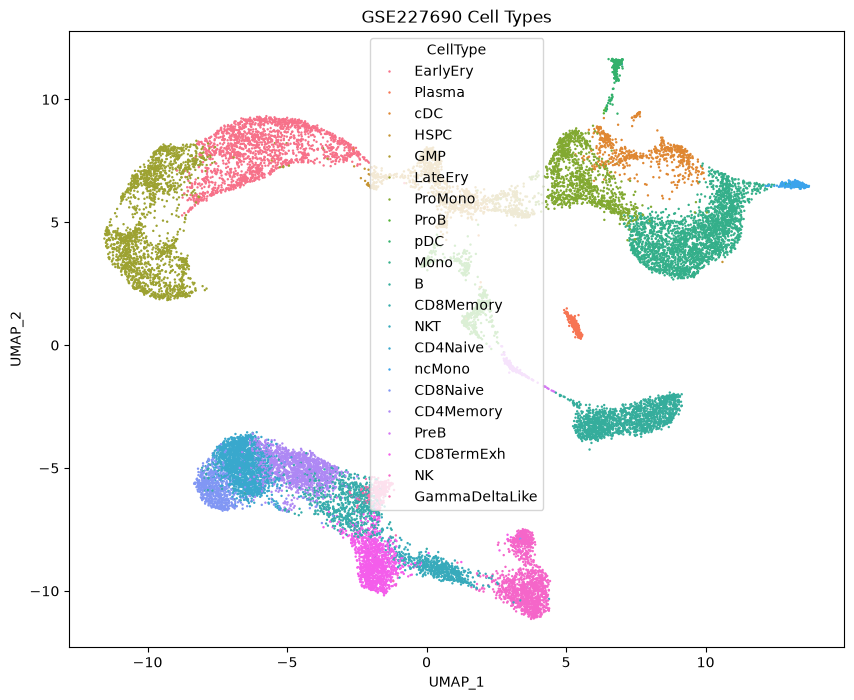

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.scatterplot(
    data=meta,
    x="UMAP_1",
    y="UMAP_2",
    hue="CellType",
    s=3,
    linewidth=0
)

plt.title("GSE227690 Cell Types")
plt.show()

In [10]:
pt10 = pd.read_csv(
    "data/raw/GSE227690_Pt10Dx_metadata.tsv.gz",
    sep="\t"
)

print(pt10.shape)

pt10["CellType"].value_counts()

pt10["is_malignant"].value_counts()

(10106, 27)


is_malignant
Other           10047
Premalignant       40
Malignant          19
Name: count, dtype: int64

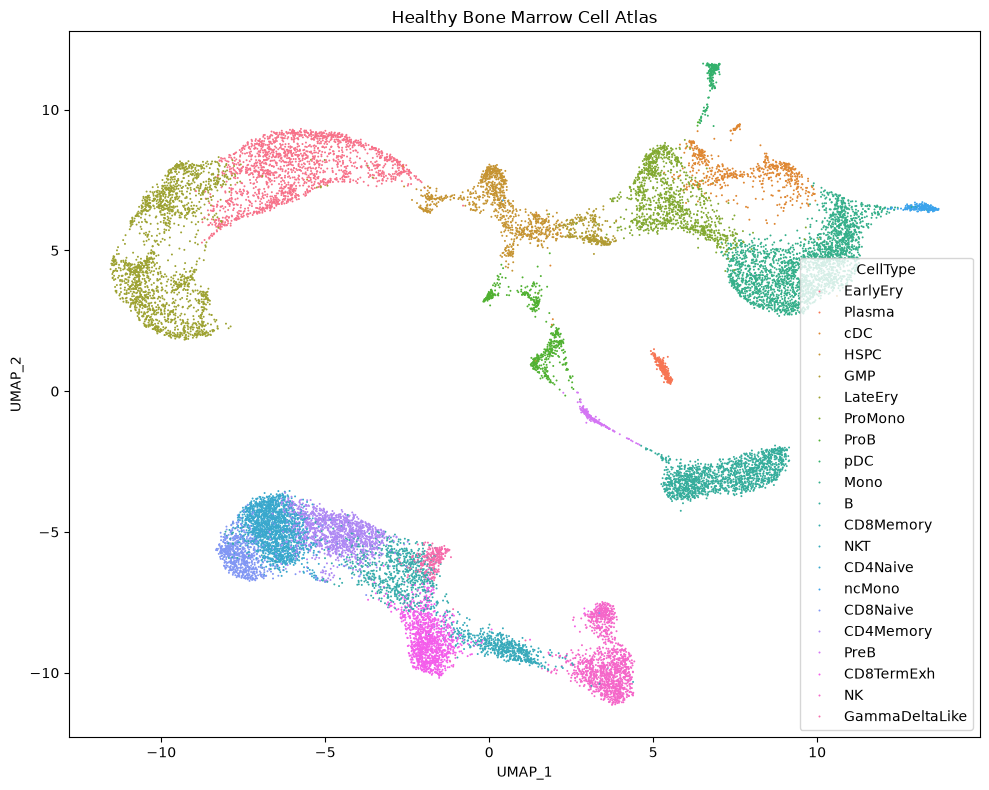

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.scatterplot(
    data=meta,
    x="UMAP_1",
    y="UMAP_2",
    hue="CellType",
    s=2,
    linewidth=0
)

plt.title("Healthy Bone Marrow Cell Atlas")
plt.tight_layout()

In [12]:
plt.savefig(
    "figures/healthy_bm_umap.png",
    dpi=300
)

<Figure size 640x480 with 0 Axes>

In [13]:
pd.crosstab(
    pt10["CellType"],
    pt10["is_malignant"]
)

is_malignant,Malignant,Other,Premalignant
CellType,,,
B,0,182,0
CD4Memory,0,1077,0
CD4Naive,0,1316,0
CD8Memory,0,185,0
CD8Naive,0,42,0
CD8TermExh,0,470,0
EarlyEry,0,183,0
GMP,0,7,0
GammaDeltaLike,0,60,0


In [14]:
import pandas as pd
from pathlib import Path

metadata_dir = Path("data/raw")

for file in metadata_dir.glob("*metadata*.gz"):
    
    df = pd.read_csv(file, sep="\t")

    print(f"\n{file.name}")

    print(df["is_malignant"].value_counts())


GSE227690_Pt12Rel_metadata.tsv.gz
is_malignant
Other        4125
Malignant    1190
Name: count, dtype: int64

GSE227690_Pt5Dx_metadata.tsv.gz
is_malignant
Other           4106
Premalignant      39
Name: count, dtype: int64

GSE227690_Pt1Dx_metadata.tsv.gz
is_malignant
Other        2341
Malignant     132
Name: count, dtype: int64

GSE227690_Pt1Rem_metadata.tsv.gz
is_malignant
Other           10297
Premalignant       15
Name: count, dtype: int64

GSE227690_Pt16Dx_metadata.tsv.gz
is_malignant
Malignant    4117
Other         335
Name: count, dtype: int64

GSE227690_Pt9Dx_metadata.tsv.gz
is_malignant
Other           4455
Premalignant     136
Malignant          2
Name: count, dtype: int64

GSE227690_Pt12Dx_metadata.tsv.gz
is_malignant
Other           6595
Premalignant     265
Malignant          2
Name: count, dtype: int64

GSE227690_Pt14Dx_metadata.tsv.gz
is_malignant
Other        6213
Malignant    1161
Name: count, dtype: int64

GSE227690_BM_metadata.tsv.gz
is_malignant
Other      20208
He

In [15]:
pd.crosstab(
    df["CellType"],
    df["is_malignant"]
)

is_malignant,Malignant,Other,Premalignant
CellType,,,
B,0,182,0
CD4Memory,0,1077,0
CD4Naive,0,1316,0
CD8Memory,0,185,0
CD8Naive,0,42,0
CD8TermExh,0,470,0
EarlyEry,0,183,0
GMP,0,7,0
GammaDeltaLike,0,60,0


In [16]:
pt10rel = pd.read_csv(
    "data/raw/GSE227690_Pt10Rel_metadata.tsv.gz",
    sep="\t"
)

pt10rel["is_malignant"].value_counts()

is_malignant
Malignant    4552
Other        2946
Name: count, dtype: int64

In [17]:
pd.crosstab(
    pt10rel["CellType"],
    pt10rel["is_malignant"]
)


is_malignant,Malignant,Other
CellType,,
B,0,22
CD4Memory,1,286
CD4Naive,0,132
CD8Memory,0,44
CD8Naive,0,93
CD8TermExh,0,61
EarlyEry,0,220
GMP,0,2
GammaDeltaLike,0,6
